<a href="https://colab.research.google.com/github/AleR26/ColabFiles/blob/main/analisis_de_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos
##Procesamiento de Lenguaje Natural
##Alejandra Rivas


### Funciones de Procesamiento de Texto y Visualización

A continuación, se definen funciones para encapsular las etapas de preprocesamiento de texto, tokenización, eliminación de stopwords y visualización.

In [2]:
import pandas as pd
import regex as re
import spacy
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 98.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
def load_df():
    texto = """
    En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.

    @Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.

    Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.

    El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital

    Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial

    y la inteligencia artificial aparecen repetidamente en los debates académicos."""
    display(texto)
    return texto

def preprocess_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^A-z\s]', ' ', texto)
    return texto

def tokenization(df):
    nlp = spacy.load('es_core_news_sm')
    docs = nlp(df)
    tokens = [token.text for token in docs]
    print("Tokenización")
    print(tokens)
    stop_words  = set(nltk.corpus.stopwords.words('spanish'))
    tokens_clean = [word for word in tokens if word not in stop_words]
    print("Sin stopwords")
    print(tokens_clean)
    return tokens_clean

def lematizacion(tokens_list):
  nlp = spacy.load('es_core_news_sm')
  text = ' '.join(tokens_list)
  docs = nlp(text)
  lemmas = [token.lemma_ for token in docs if not token.is_punct and not token.is_space]
  print(lemmas)
  return lemmas # Return lemmas for potential further use


def plot_df(tokens):
    counter = Counter(tokens)
    most_common = counter.most_common(20)
    palabras, freqs = zip(*most_common)
    plt.figure(figsize=(30,5))
    plt.bar(palabras,freqs)
    plt.title('\n Las 20 palabras más importantes')
    plt.show()

def wordcloud_df(tokens):
    text_joined = ' '.join(tokens)
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_joined)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("\n WordCloud de palabras limpias")
    plt.show()

df = load_df()
df = preprocess_texto(df)
tokens = tokenization(df)
lemas = lematizacion(tokens)


'\n    En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.\n\n    @Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.\n\n    Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.\n\n    El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital\n\n    Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial\n\n    y la inteligencia artificial aparecen repetidamente en los debates académicos.'

Tokenización
['\n    ', 'en', 'el', 'congreso', 'internacional', 'de', 'inteligencia', 'artificial', '     ', 'se', 'discutieron', 'avances', 'muy', 'importantes', '\n\n     ', 'maria', 'coment', ' ', 'que', 'la', ' ', 'tica', 'de', 'la', 'ia', 'debe', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'las', 'investigaciones', '\n\n    ', 'puedes', 'leer', 'm', 's', 'en', 'http', '  ', 'ia', 'congreso', '    ', 'org', 'o', 'enviar', 'tus', 'dudas', 'al', 'correo', 'contacto', 'ia', '    ', 'org', '\n\n    ', 'el', 'dr', ' ', 'p', 'rez', 'afirm', '    ', 'la', 'innovaci', 'n', 'no', 'se', 'detiene', '    ', 'inteligenciaartificial', '  ', 'ticadigital', '\n\n    ', 'adem', 's', ' ', 'varios', 'expertos', 'se', 'alaron', 'que', 'la', 'inteligencia', 'artificial', ' ', 'la', 'inteligencia', 'artificial', '\n\n    ', 'y', 'la', 'inteligencia', 'artificial', 'aparecen', 'repetidamente', 'en', 'los', 'debates', 'acad', 'micos']
Sin stopwords
['\n    ', 'congreso', 'internacional', 'inteligenci

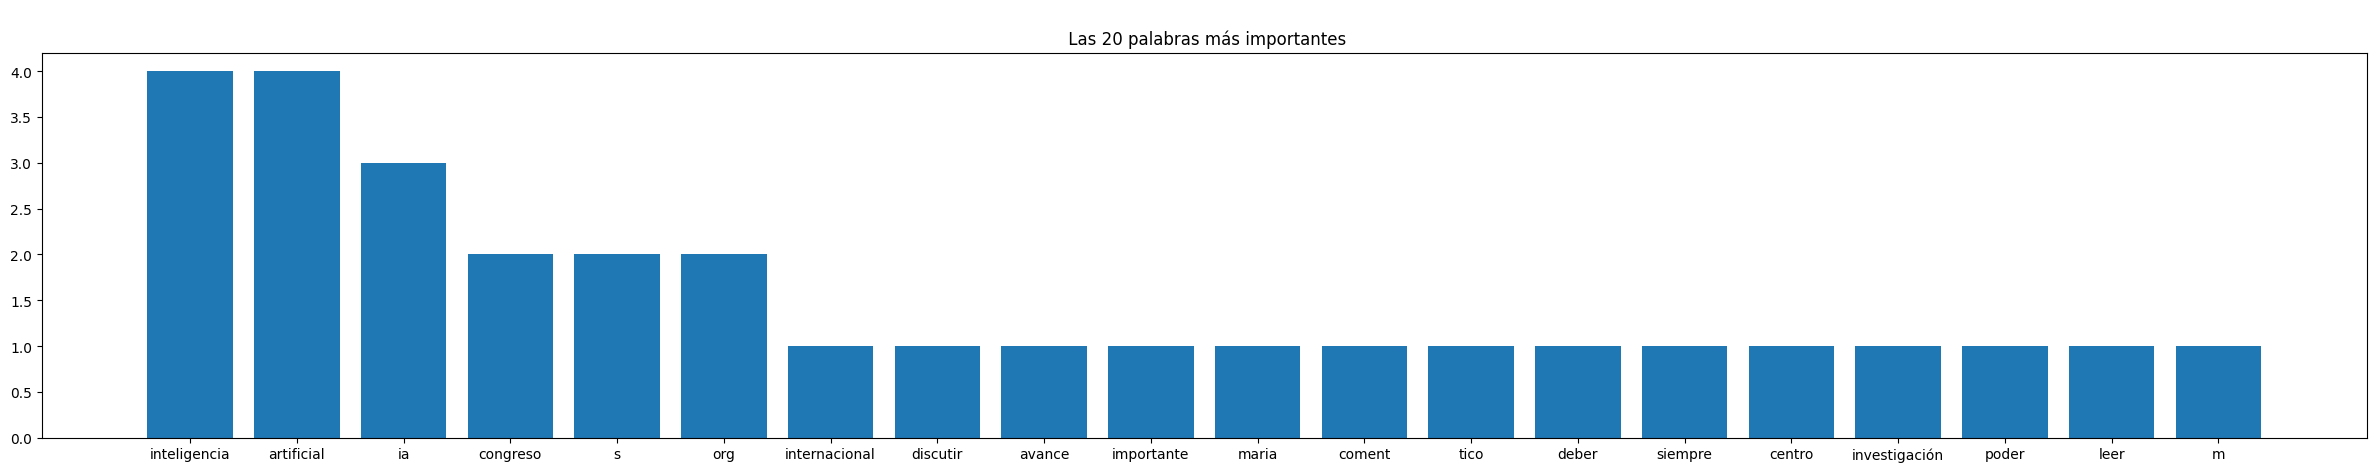

In [22]:
plot_df(lemas)


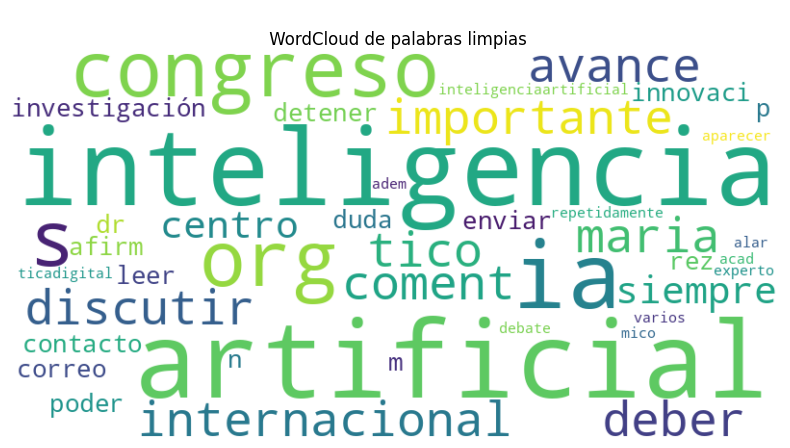

In [23]:
wordcloud_df(lemas)